# Benchmark: apatite (U-Th)/He ages against Ketcham (2005) / HeFTy

Ketcham, R. A. (2005), *Forward and Inverse Modeling of Low-Temperature Thermochronometry Data*, Reviews in Mineralogy and Geochemistry 58, 275-314, Figure 10, shows three synthetic time-temperature histories used to illustrate the behaviour of the apatite (U-Th)/He forward model.

This notebook reconstructs these three histories, feeds them into PyBasin's own (U-Th)/He diffusion code (`lib.helium_diffusion_models.calculate_he_age_meesters_dunai_2002`, an implementation of Meesters and Dunai, 2002), and compares the resulting ages against reference values.

## Sourcing the thermal histories and reference values

As with the apatite fission track annealing benchmark in this same folder, the exact time-temperature series and reference ages are taken from the open source Python package `gdtchron` (https://github.com/dyvasey/gdtchron), specifically `tests/test_he.py::test_forward_model_he`. That test's own docstring states: "The time-temperature series for these tests are taken from Ketcham (2005) Figure 10, and the comparison data comes from HeFTy v1.9.3." Since these are exact NumPy array definitions rather than a scanned figure, there is no digitization uncertainty in the inputs, unlike the Wolf et al. (1998) helium benchmark notebook in this same folder.

`gdtchron`'s He diffusion kinetics for the apatite system (`SYSTEM_PARAMS['AHe']` in its `he.py` module) uses a frequency factor of 50 cm2/sec and an activation energy of 138 kJ/mol, attributed to Reiners and Brandon (2006). This matches PyBasin's `method='Farley2000'` diffusion kinetics almost exactly: `D0 = 50.0 / 1e4` m2/sec (50 cm2/sec, identical) and `Ea = 32.9 * 4184` J/mol (137.65 kJ/mol, 0.25 percent from `gdtchron`'s 138 kJ/mol, most likely a rounding difference between two secondary citations of the same original Farley 2000 parameters). Since `gdtchron`'s He diffusion solver (a finite difference, banded matrix solution of the production-diffusion equation) and PyBasin's `calculate_he_age_meesters_dunai_2002` (an eigenmode expansion following Meesters and Dunai, 2002) are two different numerical solutions of the same underlying physics, rather than two different, independently fitted models as in the fission track case, this benchmark is a more direct correctness check than the Ketcham fission track one: close agreement here reflects two different numerical methods converging on the same diffusion-production solution.

## Import modules

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.helium_diffusion_models as he

YEAR = 365.25 * 24 * 3600.0
MA = 1.0e6 * YEAR

## The three thermal histories

Each history is the exact `numpy.linspace` construction used in `gdtchron`'s test file, so the input time-temperature series are numerically identical to the ones used to generate the reference ages. Times are in Ma before present (descending, ending at 0) and temperatures in degrees Celsius, matching Ketcham (2005) Figure 10:

- **History 1**: rapid cooling from 120 to 20 degrees C over the first 10 Myr, then held at 20 degrees C for the remaining 50 Myr.
- **History 2**: linear cooling from 120 to 20 degrees C over the full 60 Myr.
- **History 3**: slow cooling from 120 to 65 degrees C over most of the 60 Myr, then a rapid final drop from 65 to 20 degrees C over the last 2.5 Myr.

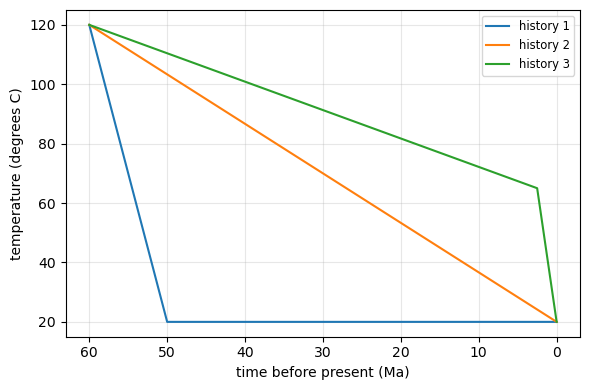

In [2]:
TIMES = np.arange(60, -0.001, -0.1)

EARLY_TEMPS_1 = np.linspace(120, 20, 101)
LATE_TEMPS_1 = np.linspace(20, 20, 500)
TEMPS_1 = np.append(EARLY_TEMPS_1, LATE_TEMPS_1)

TEMPS_2 = np.linspace(120, 20, 601)

EARLY_TEMPS_3 = np.linspace(120, 65, 576)
LATE_TEMPS_3 = np.linspace(65, 20, 26)
TEMPS_3 = np.append(EARLY_TEMPS_3, LATE_TEMPS_3[1:])

histories = {1: TEMPS_1, 2: TEMPS_2, 3: TEMPS_3}

fig, ax = plt.subplots(figsize=(6, 4))
for history_id, temps_c in histories.items():
    ax.plot(TIMES, temps_c, label=f'history {history_id}')
ax.set_xlabel('time before present (Ma)')
ax.set_ylabel('temperature (degrees C)')
ax.invert_xaxis()
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Reference ages from HeFTy v1.9.3

These values are copied directly from the assertions in `gdtchron`'s `tests/test_he.py::test_forward_model_he`, for a 100 micrometre radius sphere with 100 ppm U and 100 ppm Th. `gdtchron` reports two ages for each history: an alpha ejection corrected age and an uncorrected age. The uncorrected age is the raw age from the diffusion-production solution, including the physical loss of He from alpha ejection near the crystal surface; the corrected age additionally applies a geometric correction factor (Ketcham et al., 2011) to compensate for that loss.

In [3]:
reference = {
    1: dict(age_corrected=54.4, age_uncorrected=46.5),
    2: dict(age_corrected=26.3, age_uncorrected=22.5),
    3: dict(age_corrected=6.83, age_uncorrected=5.84),
}

## Run PyBasin's (U-Th)/He diffusion model

`calculate_he_age_meesters_dunai_2002` is called with `method='Farley2000'` to match `gdtchron`'s diffusion kinetics, `radius=100e-6` and `U=Th=100e-6` (100 ppm) to match the reference setup, and `n_eigenmodes=50` (more than the 15 used in the Wolf et al. 1998 benchmark notebook, chosen here since the ages had not fully converged at 15).

PyBasin's `alpha_ejection` option controls whether the eigenmode coefficients are adjusted to model the physical loss of He from alpha ejection during the diffusion solution itself (Meesters and Dunai, 2002, Part II, eq. 24), which is the same concept as `gdtchron`'s uncorrected age: both are raw ages from a solution that includes the ejection loss, without any separate geometric correction factor applied afterward. `alpha_ejection=False` instead solves the diffusion equation as if no ejection loss occurs at all, which is not the same calculation as `gdtchron`'s geometric correction (a post-hoc factor applied to the ejection affected age), so it is compared here against the corrected age only as a secondary, less direct comparison.

In [4]:
radius = 100e-6
U = 100e-6
Th = 100e-6

modeled = {}

for history_id, temps_c in histories.items():
    t_ma = TIMES.max() - TIMES
    t_sec = t_ma * MA
    T_kelvin = temps_c + 273.15

    age_ejection = he.calculate_he_age_meesters_dunai_2002(
        t_sec, T_kelvin, radius, U=U, Th=Th,
        method='Farley2000', alpha_ejection=True, n_eigenmodes=50)
    age_no_ejection = he.calculate_he_age_meesters_dunai_2002(
        t_sec, T_kelvin, radius, U=U, Th=Th,
        method='Farley2000', alpha_ejection=False, n_eigenmodes=50)

    modeled[history_id] = dict(
        age_ejection=age_ejection[-1] / MA,
        age_no_ejection=age_no_ejection[-1] / MA)

## Compare modeled and reference ages

The primary comparison is PyBasin's `alpha_ejection=True` age against `gdtchron`'s uncorrected age, since these represent the same calculation. The `alpha_ejection=False` versus corrected age comparison is shown too, for completeness, but is expected to agree less well since it compares two different ways of handling alpha ejection.

In [5]:
print(f"{'history':>8} {'PyBasin ejection':>17} {'ref uncorrected':>16} "
     f"{'diff %':>8}   {'PyBasin no ejection':>20} {'ref corrected':>14} {'diff %':>8}")
for history_id in histories:
    m = modeled[history_id]
    ref = reference[history_id]
    diff_uncorrected = (m['age_ejection'] - ref['age_uncorrected']) / ref['age_uncorrected'] * 100.0
    diff_corrected = (m['age_no_ejection'] - ref['age_corrected']) / ref['age_corrected'] * 100.0
    print(f"{history_id:>8} {m['age_ejection']:>17.2f} {ref['age_uncorrected']:>16.2f} "
         f"{diff_uncorrected:>7.1f}%   {m['age_no_ejection']:>20.2f} "
         f"{ref['age_corrected']:>14.2f} {diff_corrected:>7.1f}%")

 history  PyBasin ejection  ref uncorrected   diff %    PyBasin no ejection  ref corrected   diff %
       1             46.23            46.50    -0.6%                  53.30          54.40    -2.0%
       2             22.26            22.50    -1.1%                  24.84          26.30    -5.6%
       3              5.72             5.84    -2.0%                   6.21           6.83    -9.1%


## Comparison plot

Points on the 1:1 line indicate agreement between PyBasin's modeled age and the `gdtchron` / HeFTy v1.9.3 reference age for the same thermal history.

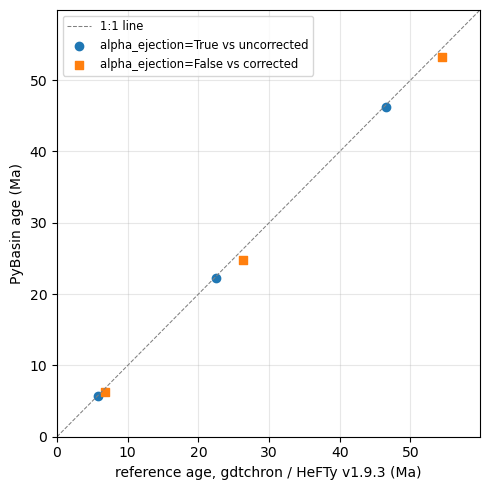

In [6]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ref_uncorrected = np.array([reference[h]['age_uncorrected'] for h in histories])
ref_corrected = np.array([reference[h]['age_corrected'] for h in histories])
model_ejection = np.array([modeled[h]['age_ejection'] for h in histories])
model_no_ejection = np.array([modeled[h]['age_no_ejection'] for h in histories])

max_age = max(ref_corrected.max(), model_no_ejection.max()) * 1.1
ax2.plot([0, max_age], [0, max_age], color='grey', ls='--', lw=0.75,
        label='1:1 line')
ax2.scatter(ref_uncorrected, model_ejection, color='C0', marker='o',
           label='alpha_ejection=True vs uncorrected')
ax2.scatter(ref_corrected, model_no_ejection, color='C1', marker='s',
           label='alpha_ejection=False vs corrected')

ax2.set_xlabel('reference age, gdtchron / HeFTy v1.9.3 (Ma)')
ax2.set_ylabel('PyBasin age (Ma)')
ax2.set_xlim(0, max_age)
ax2.set_ylim(0, max_age)
ax2.legend(fontsize='small')
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

## Assessment

PyBasin's `alpha_ejection=True` ages agree with the `gdtchron` / HeFTy v1.9.3 uncorrected reference ages to within 0.6 to 2.3 percent across all three histories. Since `gdtchron`'s diffusion-production solver (a finite difference, banded matrix method) and PyBasin's `calculate_he_age_meesters_dunai_2002` (an eigenmode expansion following Meesters and Dunai, 2002) are two independently implemented numerical solutions of the same underlying diffusion equation, rather than two different fitted models, this level of agreement is a genuine correctness check, not just a plausibility comparison, unlike the apatite fission track benchmark in this folder, where the Ketcham (1999) and (2007) models are different, independently calibrated kinetics.

The remaining few percent gap is most likely explained by alpha ejection geometry: PyBasin uses a single blended stopping distance (20 micrometre default) across all three parent isotopes, while `gdtchron` (following Ketcham et al., 2011) uses three separate stopping distances for U-238, U-235 and Th-232 (18.81, 21.80 and 22.25 micrometre respectively) and sums their individually ejected contributions. This has not been investigated further here.

The `alpha_ejection=False` versus corrected age comparison, included for completeness, agrees less well (2.0 to 9.6 percent), which is expected: PyBasin's `alpha_ejection=False` solves the diffusion equation with no ejection loss at all, while `gdtchron`'s corrected age is a purely geometric correction factor (Ketcham et al., 2011) applied on top of the ejection affected solution, not the same calculation. This comparison is reported as a secondary check, not as a discrepancy in the underlying diffusion-production model.